# Input Testing

  Rasterizing 1011 barangays...
✓ Loaded barangay data: shape (1152, 1152)
✓ Loaded metadata from metadata.json
  best_fold_idx: 0
✓ Loaded config_tuned.json
  embed_dim: 128
  num_layers: 5
  rainfall_hidden: 32
[InferenceEngine] device = cpu
[InferenceEngine] Config: embed_dim=128, num_layers=5, rainfall_hidden=32
[InferenceEngine] Loaded 6,075 Manila patches  | spatial (6075, 3, 4, 4)  | dem (1152, 1152)
[InferenceEngine] Model loaded  ← fold_1_best.pth
  Output directory: input_testing_veh
  Applying mask from manila_box_shape.tif...
  ⚠ Mask alignment: CRS=False, Shape=True
    → Reprojecting mask to match prediction...
  Mask applied: 70,333 / 1,327,104 pixels inside
✓ Saved → input_testing_veh\triangular_50mm_tp05.tif


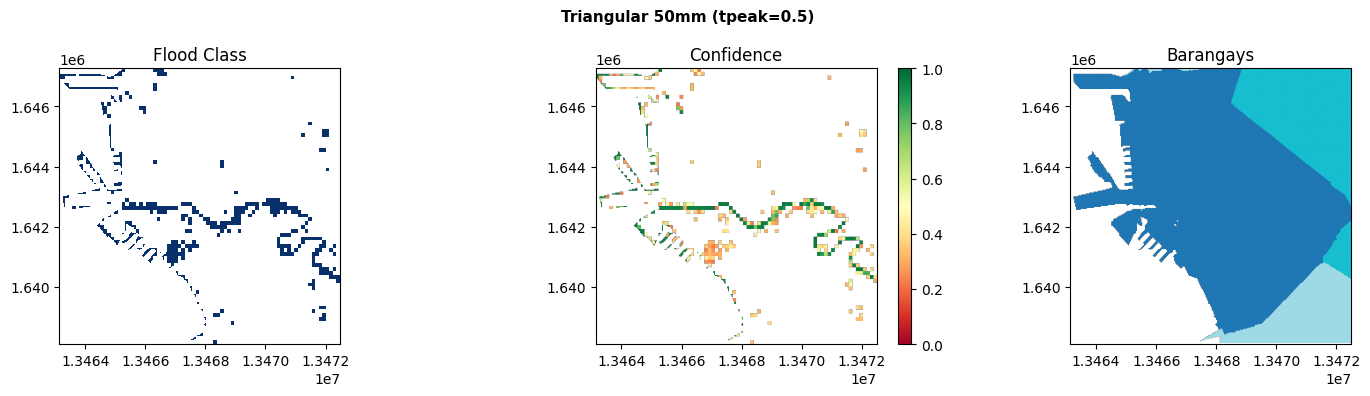

✓ File saved as: triangular_50mm_tp05.tif
File saved at: input_testing_veh\triangular_50mm_tp05.tif

✓ File saved at: input_testing_veh\triangular_50mm_tp05.tif

Summary:
  Total patches: 6075
  Flooded patches: 1967 (32.38%)
  Mean confidence: 0.7237


In [ ]:
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine
from pathlib import Path
import json

from config import TrainConfig 
from inference import ( InferenceEngine, load_barangay_band, run_inference )

cfg = TrainConfig()

# ── Visual constants ──────────────────────────────────────────────────────────
FLOOD_COLORS = {0: '#FFFFFF', 1: '#C6DBEF', 2: '#6BAED6', 3: '#2171B5', 4: '#08306B'}
FLOOD_LABELS = {0:'No Flood', 1:'Light', 2:'Moderate', 3:'Heavy', 4:'Extreme'}

# Create colormap with transparent color for class 0
colors_list = ['#FFFFFF', '#C6DBEF', '#6BAED6', '#2171B5', '#08306B']
flood_cmap = mcolors.ListedColormap(colors_list)
flood_cmap.set_under(alpha=0)  
flood_cmap.set_bad(alpha=0)   

legend_patches = [mpatches.Patch(color=FLOOD_COLORS[i], label=FLOOD_LABELS[i]) for i in range(5)]
flood_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 6)

# ── GeoTIFF save helper ───────────────────────────────────────────────────────
src_left, src_top   = 13457490.0, 1664610.0
src_W,    src_H     = 1125,       1224          
dst_W,    dst_H     = 1152,       1152          
src_right           = 13491240.0
src_bottom          = 1627890.0
new_pixel_x = (src_right  - src_left) / dst_W  
new_pixel_y = (src_bottom - src_top)  / dst_H   
dem_transform = Affine(new_pixel_x, 0.0, src_left, 0.0, new_pixel_y, src_top)
dem_crs       = rasterio.crs.CRS.from_epsg(3857)

_GEOJSON_PATH  = 'manila_barangay_geojson.geojson'
_barangay_band = load_barangay_band(
    geojson_path=_GEOJSON_PATH,
    dst_transform=dem_transform,
    dst_crs=dem_crs,
    H=dst_H,
    W=dst_W
)

print(f"✓ Loaded barangay data: shape {_barangay_band.shape}")

# ── Load best fold metadata ───────────────────────────────────────────────────
metadata_path = Path('outputs/logs_tuned/metadata.json')
with open(metadata_path) as f:
    metadata = json.load(f)
    best_fold_idx = metadata['best_fold_idx']
print(f"✓ Loaded metadata from {metadata_path.name}")
print(f"  best_fold_idx: {best_fold_idx}")

# ── Load tuned config ─────────────────────────────────────────────────────────
config_path = Path('outputs/logs_tuned/config_tuned.json')
cfg_tuned = TrainConfig.load(str(config_path))
print(f"✓ Loaded config_tuned.json")
print(f"  embed_dim: {cfg_tuned.embed_dim}")
print(f"  num_layers: {cfg_tuned.num_layers}")
print(f"  rainfall_hidden: {cfg_tuned.rainfall_hidden}")

# ── Load best checkpoint ──────────────────────────────────────────────────────
checkpoint_path = Path('outputs/checkpoints_tuned') / f'fold_{best_fold_idx+1}_best.pth'

# ── Initialize InferenceEngine ────────────────────────────────────────────────
engine = InferenceEngine(
    checkpoint_path=str(checkpoint_path),
    patch_data_path='outputs/spatial_data.npz',
    config=cfg_tuned 
)
import os
repo_root = os.getcwd()
manila_mask = os.path.join(repo_root, "manila_box_shape.tif")

# Single call for a Triangular storm
res = run_inference(
    engine          = engine,
    storm_type      = 'triangular',
    depth_mm        = 50.0,
    tpeak           = 0.5,
    output_dir      = Path('./input_testing_veh'),
    dem_transform   = dem_transform,
    dem_crs         = dem_crs,
    barangay_band   = _barangay_band,
    mask_tif_path   = manila_mask 
)
print(f"File saved at: {res['tif_path']}")
print(f"\n✓ File saved at: {res['tif_path']}")
print(f"\nSummary:")
print(f"  Total patches: {res['total_patches']}")
print(f"  Flooded patches: {res['flooded_patches']} ({res['flooded_pct']}%)")
print(f"  Mean confidence: {res['mean_confidence']}")